# 03 — Majority Class Baseline

Predicts non-toxic (class 0) for every comment. Sets the performance floor and
proves why accuracy is a useless metric on this dataset.

**Prerequisites:** Run `preprocessing.ipynb` first.

**Outputs:**
- `results/majority_baseline.json` — metrics loaded by analysis notebook

In [1]:
import sys, os, json
sys.path.append('..')

import numpy as np
import pandas as pd
from pathlib import Path

from src.data_utils import load_splits
from src.evaluation import evaluate

os.makedirs('../results', exist_ok=True)
print("Imports OK")


Imports OK


## 1. Load test split

In [2]:
_, _, test = load_splits('../data')
print(f"Test set: {len(test):,} rows")
print(f"Toxic: {test['label'].sum():,}  ({test['label'].mean():.2%})")
print(f"Non-toxic: {(test['label']==0).sum():,}  ({(test['label']==0).mean():.2%})")


Test set: 15,958 rows
Toxic: 1,623  (10.17%)
Non-toxic: 14,335  (89.83%)


## 2. Predict majority class

In [3]:
y_true = test['label'].values
y_pred = np.zeros(len(y_true), dtype=int)  # always predict non-toxic

print(f"Predicting class 0 (non-toxic) for all {len(y_pred):,} examples.")
print(f"Naive accuracy: {(y_pred == y_true).mean():.2%}")


Predicting class 0 (non-toxic) for all 15,958 examples.
Naive accuracy: 89.83%


## 3. Evaluate


  Majority Class Baseline
              precision    recall  f1-score   support

   non-toxic     0.8983    1.0000    0.9464     14335
       toxic     0.0000    0.0000    0.0000      1623

    accuracy                         0.8983     15958
   macro avg     0.4491    0.5000    0.4732     15958
weighted avg     0.8069    0.8983    0.8502     15958



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


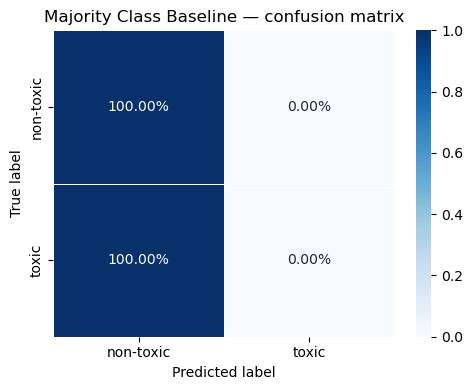

In [4]:
results = evaluate(y_true, y_pred, model_name='Majority Class Baseline')


## 4. Interpretation

The majority baseline gets ~90% accuracy by never predicting toxic once.
F1 on the toxic class is **0.0** — it has zero recall because it never catches
a single toxic comment.

This is exactly why accuracy is the wrong metric here. Any model we build
must beat this on **F1 (toxic class)**, not accuracy. NBOW+LR and DistilBERT
are evaluated against this floor in notebook 06.

In [5]:
# Save for notebook 06
with open('../results/majority_baseline.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f"Saved → ../results/majority_baseline.json")
print(json.dumps(results, indent=2))


Saved → ../results/majority_baseline.json
{
  "model": "Majority Class Baseline",
  "f1_toxic": 0.0,
  "precision_toxic": 0.0,
  "recall_toxic": 0.0,
  "f1_nontoxic": 0.9464,
  "f1_macro": 0.4732,
  "f1_weighted": 0.8502
}
